In [1]:
import pandas as pd

df = pd.read_csv("../data/tiktok_posts.csv")

df.head()

,Date,total views,Video,likes,comments,fave,Type,tiktok stat,category,typo,notes
0,1/1/2026,306.0,2025 recap,10.0,3.0,0.0,vlog style,trend audio,NaN,NaN,NaN
1,1/1/2026,532.0,Heathrow at 8am,37.0,0.0,0.0,spam style,trend audio,travel,NaN,NaN
2,1/2/2026,552.0,Jelly cat hunting,46.0,2.0,1.0,vlog style,trend audio,knick knacks,NaN,NaN
3,1/2/2026,329.0,help...(Jelly cat),18.0,1.0,1.0,tiktok style,trend audio,knick knacks,NaN,NaN
4,1/3/2026,408.0,walking in suburbs,24.0,4.0,0.0,tiktok style,trend audio,NaN,NaN,NaN


In [2]:
df.columns

Index(['Date', 'total views', 'Video ', 'likes', 'comments ', 'fave', 'Type',
       'tiktok stat', 'category ', 'typo ', 'notes'],
      dtype='str')

In [4]:
df.isnull().sum()

Date             3
total views      4
Video            4
likes            4
comments         4
fave             4
Type             4
tiktok stat      4
category        48
typo            22
notes          258
dtype: int64

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.columns

Index(['date', 'total_views', 'video', 'likes', 'comments', 'fave', 'type',
       'tiktok_stat', 'category', 'typo', 'notes'],
      dtype='str')

In [6]:
df["date"] = pd.to_datetime(df["date"])

df.info()

ValueError: time data "numbers as 5/6/2026" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [7]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         260 non-null    datetime64[us]
 1   total_views  260 non-null    float64       
 2   video        260 non-null    str           
 3   likes        260 non-null    float64       
 4   comments     260 non-null    float64       
 5   fave         260 non-null    float64       
 6   type         260 non-null    str           
 7   tiktok_stat  260 non-null    str           
 8   category     216 non-null    str           
 9   typo         242 non-null    str           
 10  notes        6 non-null      str           
dtypes: datetime64[us](1), float64(4), str(6)
memory usage: 36.2 KB


In [8]:
df[df["date"].isna()]

,date,total_views,video,likes,comments,fave,type,tiktok_stat,category,typo,notes
260,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.dropna(subset=["date"])

In [10]:
## Engagement Metrics 
df["engagement_rate"] = (
    df["likes"] + df["comments"] + df["fave"]
) / df["total_views"]

df["like_rate"] = df["likes"] / df["total_views"]

df["comment_rate"] = df["comments"] / df["total_views"]

df["favorite_rate"] = df["fave"] / df["total_views"]

df.head()

,date,total_views,video,likes,comments,fave,type,tiktok_stat,category,typo,notes,engagement_rate,like_rate,comment_rate,favorite_rate
0,2026-01-01,306.0,2025 recap,10.0,3.0,0.0,vlog style,trend audio,NaN,NaN,NaN,0.042484,0.032680,0.009804,0.000000
1,2026-01-01,532.0,Heathrow at 8am,37.0,0.0,0.0,spam style,trend audio,travel,NaN,NaN,0.069549,0.069549,0.000000,0.000000
2,2026-01-02,552.0,Jelly cat hunting,46.0,2.0,1.0,vlog style,trend audio,knick knacks,NaN,NaN,0.088768,0.083333,0.003623,0.001812
3,2026-01-02,329.0,help...(Jelly cat),18.0,1.0,1.0,tiktok style,trend audio,knick knacks,NaN,NaN,0.060790,0.054711,0.003040,0.003040
4,2026-01-03,408.0,walking in suburbs,24.0,4.0,0.0,tiktok style,trend audio,NaN,NaN,NaN,0.068627,0.058824,0.009804,0.000000


In [11]:
df = df.drop(columns=["typo", "notes"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             260 non-null    datetime64[us]
 1   total_views      260 non-null    float64       
 2   video            260 non-null    str           
 3   likes            260 non-null    float64       
 4   comments         260 non-null    float64       
 5   fave             260 non-null    float64       
 6   type             260 non-null    str           
 7   tiktok_stat      260 non-null    str           
 8   category         216 non-null    str           
 9   engagement_rate  260 non-null    float64       
 10  like_rate        260 non-null    float64       
 11  comment_rate     260 non-null    float64       
 12  favorite_rate    260 non-null    float64       
dtypes: datetime64[us](1), float64(8), str(4)
memory usage: 39.2 KB


In [12]:
df["category"] = df["category"].fillna("uncategorized")

df["category"].value_counts()

category
TV/movies             70
uncategorized         44
food                  44
friends               31
travel                27
Museum                14
knick knacks          11
family                 7
booktok                3
travel, friends        2
food, knick knacks     2
friends, food          1
TV/movies, travel      1
TV/movies, booktok     1
friends, Museum        1
food, friends          1
Name: count, dtype: int64

In [13]:
df["month"] = df["date"].dt.month_name()
df["day_of_week"] = df["date"].dt.day_name()
df["week"] = df["date"].dt.isocalendar().week

df.head()

,date,total_views,video,likes,comments,fave,type,tiktok_stat,category,engagement_rate,like_rate,comment_rate,favorite_rate,month,day_of_week,week
0,2026-01-01,306.0,2025 recap,10.0,3.0,0.0,vlog style,trend audio,uncategorized,0.042484,0.032680,0.009804,0.000000,January,Thursday,1
1,2026-01-01,532.0,Heathrow at 8am,37.0,0.0,0.0,spam style,trend audio,travel,0.069549,0.069549,0.000000,0.000000,January,Thursday,1
2,2026-01-02,552.0,Jelly cat hunting,46.0,2.0,1.0,vlog style,trend audio,knick knacks,0.088768,0.083333,0.003623,0.001812,January,Friday,1
3,2026-01-02,329.0,help...(Jelly cat),18.0,1.0,1.0,tiktok style,trend audio,knick knacks,0.060790,0.054711,0.003040,0.003040,January,Friday,1
4,2026-01-03,408.0,walking in suburbs,24.0,4.0,0.0,tiktok style,trend audio,uncategorized,0.068627,0.058824,0.009804,0.000000,January,Saturday,1


In [14]:
## Weekend flag 
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

df[["date", "day_of_week", "is_weekend"]].head()

,date,day_of_week,is_weekend
0,2026-01-01,Thursday,False
1,2026-01-01,Thursday,False
2,2026-01-02,Friday,False
3,2026-01-02,Friday,False
4,2026-01-03,Saturday,True


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             260 non-null    datetime64[us]
 1   total_views      260 non-null    float64       
 2   video            260 non-null    str           
 3   likes            260 non-null    float64       
 4   comments         260 non-null    float64       
 5   fave             260 non-null    float64       
 6   type             260 non-null    str           
 7   tiktok_stat      260 non-null    str           
 8   category         260 non-null    str           
 9   engagement_rate  260 non-null    float64       
 10  like_rate        260 non-null    float64       
 11  comment_rate     260 non-null    float64       
 12  favorite_rate    260 non-null    float64       
 13  month            260 non-null    str           
 14  day_of_week      260 non-null    str           
 15  

In [16]:
df.to_csv("../outputs/clean_tiktok_data.csv", index=False)

In [17]:
clean_df = pd.read_csv("../outputs/clean_tiktok_data.csv")
clean_df.head()

,date,total_views,video,likes,comments,fave,type,tiktok_stat,category,engagement_rate,like_rate,comment_rate,favorite_rate,month,day_of_week,week,is_weekend
0,2026-01-01,306.0,2025 recap,10.0,3.0,0.0,vlog style,trend audio,uncategorized,0.042484,0.032680,0.009804,0.000000,January,Thursday,1,False
1,2026-01-01,532.0,Heathrow at 8am,37.0,0.0,0.0,spam style,trend audio,travel,0.069549,0.069549,0.000000,0.000000,January,Thursday,1,False
2,2026-01-02,552.0,Jelly cat hunting,46.0,2.0,1.0,vlog style,trend audio,knick knacks,0.088768,0.083333,0.003623,0.001812,January,Friday,1,False
3,2026-01-02,329.0,help...(Jelly cat),18.0,1.0,1.0,tiktok style,trend audio,knick knacks,0.060790,0.054711,0.003040,0.003040,January,Friday,1,False
4,2026-01-03,408.0,walking in suburbs,24.0,4.0,0.0,tiktok style,trend audio,uncategorized,0.068627,0.058824,0.009804,0.000000,January,Saturday,1,True


In [18]:
## EDA
## Views Distribution 
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


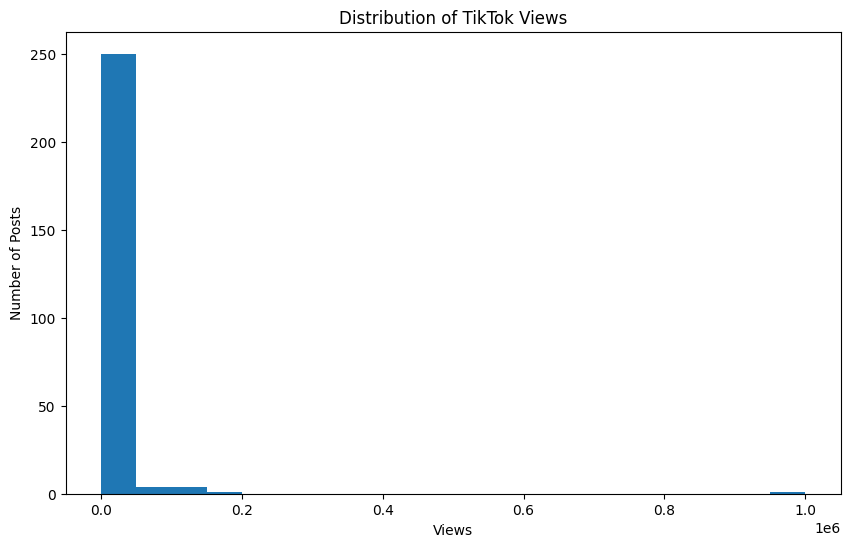

In [19]:
plt.figure(figsize=(10,6))

plt.hist(df["total_views"], bins=20)

plt.xlabel("Views")
plt.ylabel("Number of Posts")
plt.title("Distribution of TikTok Views")

plt.show()

In [ ]:
majority of the videos are dying out at 250 viewa and very few are going viral which makes sense 
virality appears to be skewed 

In [24]:
## AVG Engagement 
category_engagement = (
    df.groupby("category")["engagement_rate_pct"]
    .mean()
    .sort_values(ascending=False)
)

category_engagement

category
TV/movies, travel     27.587023
friends, Museum        9.731114
Museum                 9.516535
friends                8.715589
travel                 7.923168
food, friends          7.500000
knick knacks           7.279441
family                 7.134238
TV/movies              6.838985
TV/movies, booktok     6.561361
uncategorized          5.601239
travel, friends        5.547457
booktok                4.990799
food                   4.954547
food, knick knacks     4.637082
friends, food          3.571429
Name: engagement_rate_pct, dtype: float64

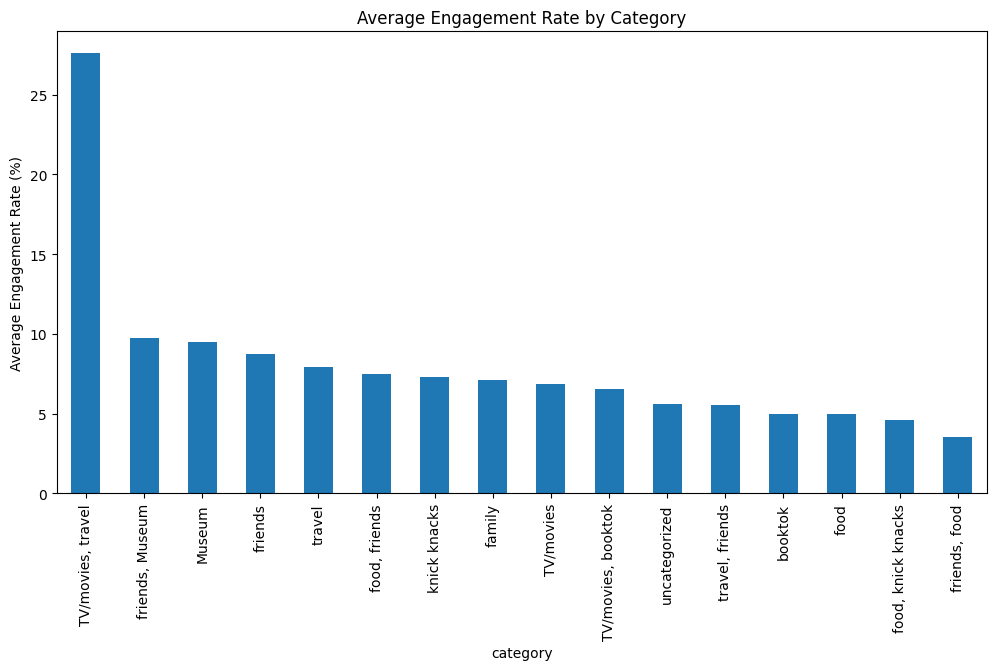

In [25]:
plt.figure(figsize=(12,6))

category_engagement.plot(kind="bar")

plt.ylabel("Average Engagement Rate (%)")
plt.title("Average Engagement Rate by Category")

plt.show()

As suspected tv/movies and travel are doing the best 
I have to revisit the code on this bc the doubles are skewing the data 

In [22]:
df["engagement_rate_pct"] = df["engagement_rate"] * 100

df["like_rate_pct"] = df["like_rate"] * 100

df["comment_rate_pct"] = df["comment_rate"] * 100

df["favorite_rate_pct"] = df["favorite_rate"] * 100

In [26]:
## Posting frequency
posting_days = df["day_of_week"].value_counts()

posting_days

day_of_week
Wednesday    43
Monday       40
Sunday       37
Thursday     36
Saturday     35
Tuesday      35
Friday       34
Name: count, dtype: int64

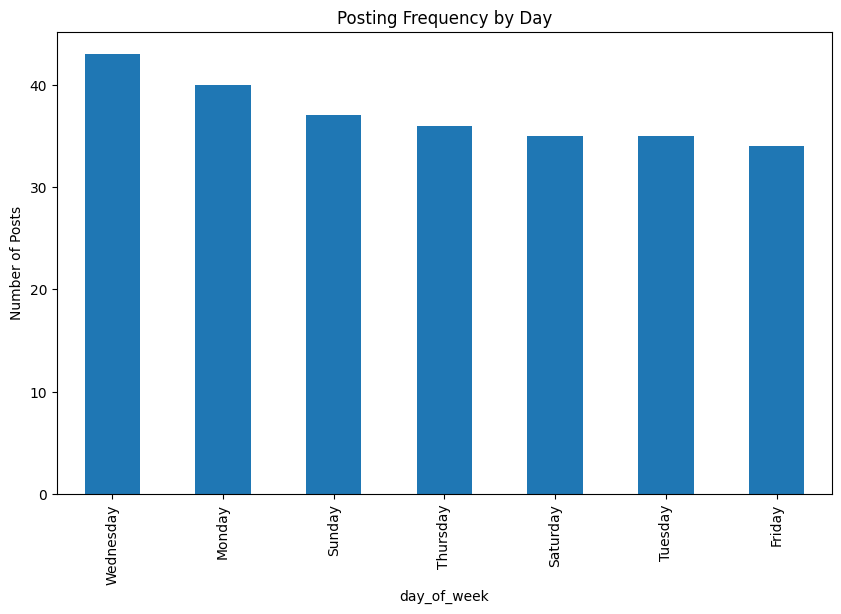

In [27]:
plt.figure(figsize=(10,6))

posting_days.plot(kind="bar")

plt.ylabel("Number of Posts")
plt.title("Posting Frequency by Day")

plt.show()

Affinity to post on wednesdays 

In [28]:
## Average Views by Day
views_by_day = (
    df.groupby("day_of_week")["total_views"]
    .mean()
)

views_by_day

day_of_week
Friday        4523.264706
Monday        3605.000000
Saturday      7816.171429
Sunday        3244.972973
Thursday     37185.694444
Tuesday       1413.857143
Wednesday     5242.744186
Name: total_views, dtype: float64

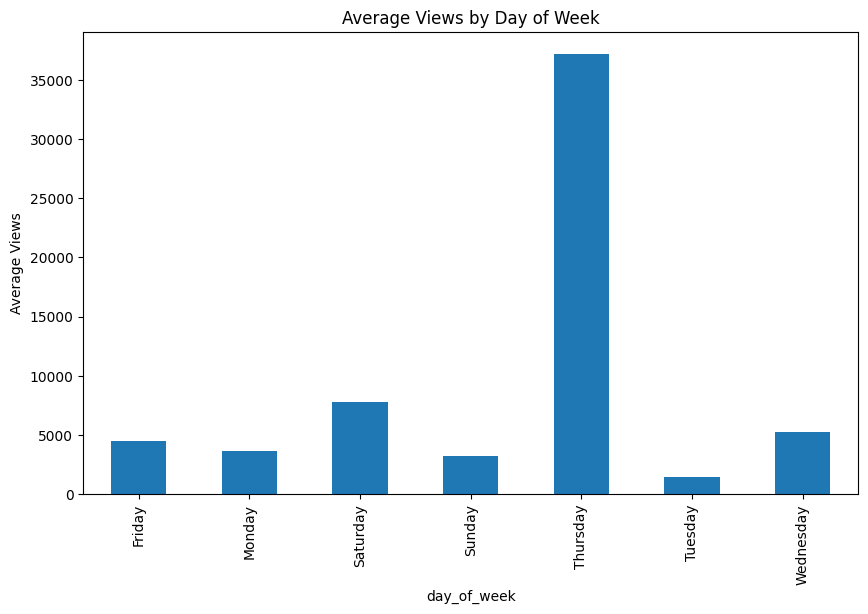

In [29]:
plt.figure(figsize=(10,6))

views_by_day.plot(kind="bar")

plt.ylabel("Average Views")
plt.title("Average Views by Day of Week")

plt.show()

Thursday is the best day for my brand of virality and tuesday in the worst 

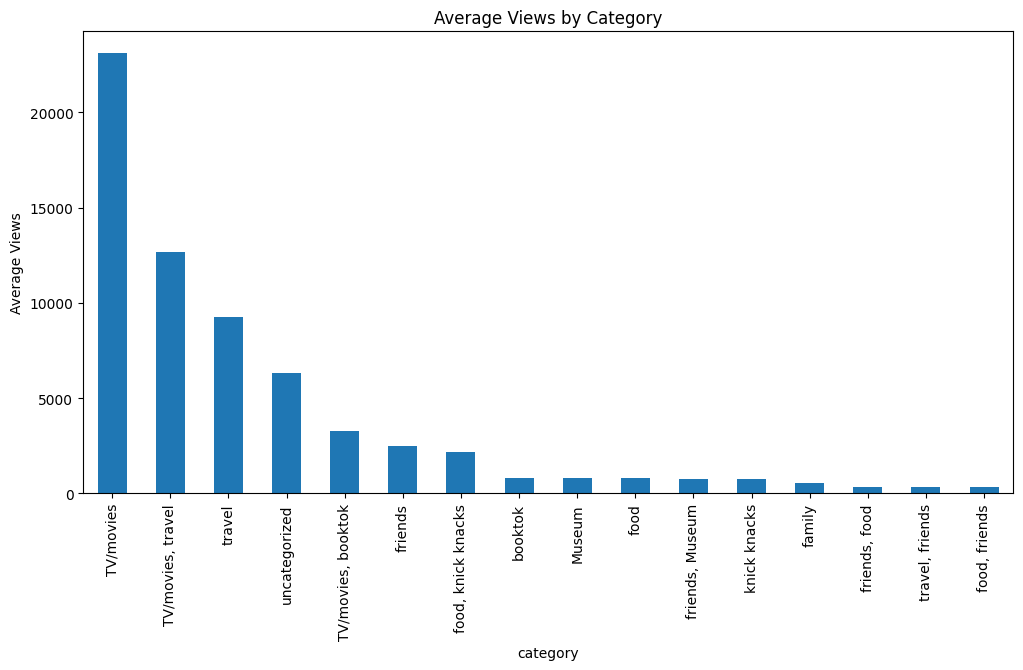

In [30]:
## Top categories by views
top_categories = (
    df.groupby("category")["total_views"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

top_categories.plot(kind="bar")

plt.ylabel("Average Views")
plt.title("Average Views by Category")

plt.show()

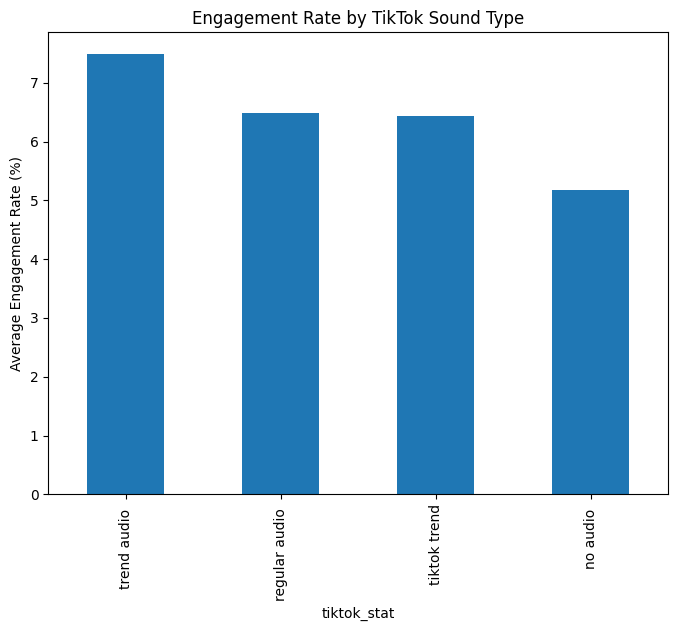

In [31]:
## Tiktok sound performance 
sound_performance = (
    df.groupby("tiktok_stat")["engagement_rate_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

sound_performance.plot(kind="bar")

plt.ylabel("Average Engagement Rate (%)")
plt.title("Engagement Rate by TikTok Sound Type")

plt.show()

In [32]:
df.to_csv("../outputs/clean_tiktok_data.csv", index=False)

In [33]:
df["category"].unique()

<ArrowStringArray>
[     'uncategorized',             'travel',       'knick knacks',
             'family',          'TV/movies',            'friends',
             'Museum',            'booktok',               'food',
      'friends, food',  'TV/movies, travel',    'travel, friends',
 'TV/movies, booktok',    'friends, Museum', 'food, knick knacks',
      'food, friends']
Length: 16, dtype: str

In [34]:
df["category"] = df["category"].str.split(",").str[0]

In [35]:
df["category"] = df["category"].str.strip()

In [36]:
df["category"].value_counts()

category
TV/movies        72
food             47
uncategorized    44
friends          33
travel           29
Museum           14
knick knacks     11
family            7
booktok           3
Name: count, dtype: int64

In [37]:
df["category"] = df["category"].astype(str).str.split(",").str[0].str.strip()

df["category"].value_counts()

category
TV/movies        72
food             47
uncategorized    44
friends          33
travel           29
Museum           14
knick knacks     11
family            7
booktok           3
Name: count, dtype: int64

In [38]:
df.to_csv("../outputs/clean_tiktok_data.csv", index=False)